# 05 · HEC-HMS + HEC-RAS — Hydrological and hydraulic simulation

The selected events are reconstructed as **synthetic hyetographs** from their four parameters (Pmax, Pmed, Duration, Type) using 2nd-degree polynomial fitting to the reference hyetograph shape (Navas et al., 2017).  

Simulation workflow (Figure 9 in Navas et al., 2024):  
1. **625 synthetic hyetographs** → **HEC-HMS** → 625 peak flows (Qmax)  
2. **HEC-RAS 1D** (22 reference Q values → rating curve) → **625 water depths** at Toledo Bridge (XS 6262) and Weir No.9 (XS 4112)

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR  = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
DATA_ROOT = DATA_DIR / 'pilot_cases' / 'm30_manzanares'

EVENTS_DIR   = DATA_ROOT / 'events'
RESULTS_DIR  = DATA_ROOT / 'results'
STATIONS_DIR = DATA_ROOT / 'stations'

print('DATA_ROOT:', DATA_ROOT)

T_VALS   = [2, 5, 10, 20, 50, 100, 500]
N_STAT   = 17
LAM      = 5.17    # Poisson rate (events/year)
XS_PT    = 6262    # Toledo Bridge cross-section
XS_R9    = 4112    # Weir No.9 cross-section


DATA_ROOT: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/m30_manzanares


In [2]:
depth_mv  = pd.read_csv(RESULTS_DIR / 'depth_foresee.csv',   index_col=0)
depth_cls = pd.read_csv(RESULTS_DIR / 'depth_classical.csv', index_col=0)

print('Copula-based depths (303 cross-sections × 7 return periods):')
print(depth_mv.columns.tolist())
print()
print(f'Toledo Bridge (XS {XS_PT}) — copula-based method:')
for t, c in zip(T_VALS, depth_mv.columns):
    print(f'  T={t:>4}: {depth_mv.loc[XS_PT, c]:.3f} m')

Copula-based depths (303 cross-sections × 7 return periods):
['WS Elev (m) T_2', 'WS Elev (m) T_5', 'WS Elev (m) T_10', 'WS Elev (m) T_20', 'WS Elev (m) T_50', 'WS Elev (m) T_100', 'WS Elev (m) T_500']

Toledo Bridge (XS 6262) — copula-based method:
  T=   2: 1.984 m
  T=   5: 2.855 m
  T=  10: 3.682 m
  T=  20: 4.451 m
  T=  50: 5.346 m
  T= 100: 5.999 m
  T= 500: 7.608 m


In [3]:
# Design peak flows by return period (Table 1, Navas et al., 2024)
Q_mv  = [75.4,  152.2, 230.3, 313.5, 454.7, 491.4, 739.0]
Q_cls = [60.1,  120.0, 185.4, 260.0, 387.0, 430.0, 576.1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

d_mv_pt  = depth_mv.loc[XS_PT].values
d_cls_pt = depth_cls.loc[XS_PT].values

axes[0].plot(Q_mv,  d_mv_pt,  'o-',  c='#f97316', lw=2.5, ms=8,
             label='Copula-based (Navas et al., 2024)')
axes[0].plot(Q_cls, d_cls_pt, 's--', c='#3b82f6', lw=2,   ms=6,
             label='Classical (GEV univariate)')
for t, q, d in zip(T_VALS, Q_mv, d_mv_pt):
    if t in (100, 500):
        axes[0].annotate(f'T={t}', (q, d), textcoords='offset points',
                         xytext=(6, 4), fontsize=8, color='#f97316')
axes[0].set_xlabel('Peak flow Qmax (m³/s)', fontsize=10)
axes[0].set_ylabel('Water depth — Toledo Bridge (m)', fontsize=10)
axes[0].set_title('HEC-RAS rating curve — Toledo Bridge (XS 6262)', fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Selected event cloud: log-normalised colour so minority of high-Pmax events is visible
events = pd.read_csv(EVENTS_DIR / 'events_selected.csv', index_col=0)
ev_nz  = events[(events['Pmax17'] > 0)]
pmax17 = ev_nz['Pmax17'].values

sc_p = axes[1].scatter(pmax17, ev_nz['Duracion17'].values,
                       c=np.log1p(pmax17), cmap='YlOrRd',
                       s=12, alpha=0.75, rasterized=True)
cbar = plt.colorbar(sc_p, ax=axes[1])
cbar.set_label('Pmax station 17 — log scale (mm)')
tick_vals = [0, 5, 20, 60, 120]
cbar.set_ticks(np.log1p(tick_vals))
cbar.set_ticklabels([str(v) for v in tick_vals])

axes[1].set_xlabel('Pmax station 17 (mm)')
axes[1].set_ylabel('Duration station 17 (h)')
axes[1].set_title('Selected event cloud — Pmax–Duration space', fontsize=11)
plt.tight_layout(); plt.show()

Design depths — Toledo Bridge (XS 6262):
     T |   Copula | Classical |  Diff (m)
  -----+----------+-----------+----------
  2    |    1.984 |     2.640 |    -0.656
  5    |    2.855 |     3.006 |    -0.151
  10   |    3.682 |     3.361 |    +0.321
  20   |    4.451 |     3.785 |    +0.666
  50   |    5.346 |     4.458 |    +0.889
  100  |    5.999 |     5.050 |    +0.949
  500  |    7.608 |     6.781 |    +0.826  ← design event

At T=100: copula-based exceeds classical by +0.949 m
At T=500: copula-based exceeds classical by +0.826 m  (key result, Navas et al., 2024)


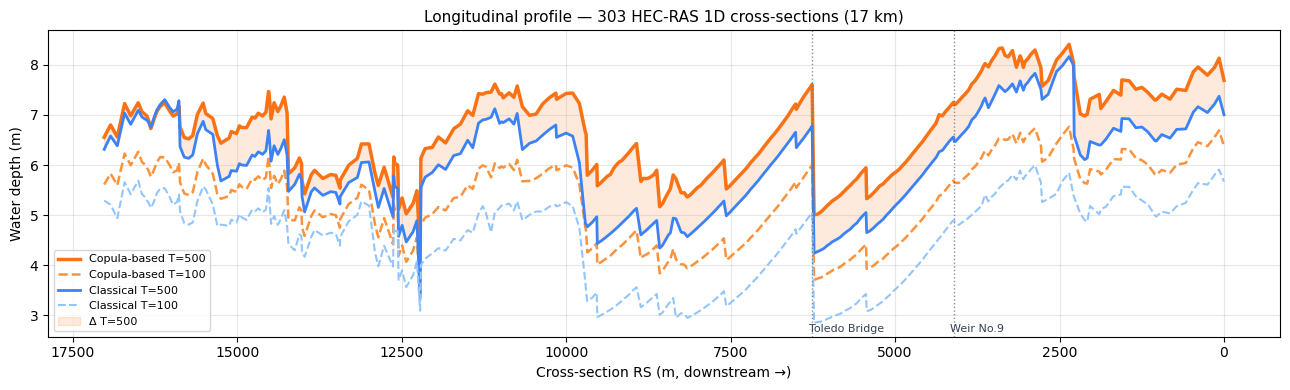

In [4]:
# Longitudinal depth profile — T=100 and T=500
xs_sorted = sorted(depth_mv.index, reverse=True)
tcols_mv  = {t: c for t, c in zip(T_VALS, depth_mv.columns)}
tcols_cls = {t: c for t, c in zip(T_VALS, depth_cls.columns)}

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(xs_sorted, depth_mv.loc[xs_sorted,  tcols_mv[500]],
        '-',  c='#f97316', lw=2.5, label='Copula-based T=500')
ax.plot(xs_sorted, depth_mv.loc[xs_sorted,  tcols_mv[100]],
        '--', c='#fb923c', lw=1.8, label='Copula-based T=100')
ax.plot(xs_sorted, depth_cls.loc[xs_sorted, tcols_cls[500]],
        '-',  c='#3b82f6', lw=2,   label='Classical T=500')
ax.plot(xs_sorted, depth_cls.loc[xs_sorted, tcols_cls[100]],
        '--', c='#93c5fd', lw=1.5, label='Classical T=100')
ax.fill_between(xs_sorted,
                depth_cls.loc[xs_sorted, tcols_cls[500]],
                depth_mv.loc[xs_sorted,  tcols_mv[500]],
                alpha=0.15, color='#f97316', label='Δ T=500')

for xs, name in [(XS_PT, 'Toledo Bridge'), (XS_R9, 'Weir No.9')]:
    ax.axvline(xs, color='#6b7280', lw=1, linestyle=':', alpha=0.8)
    ax.text(xs+50, ax.get_ylim()[0]+0.1, name, ha='left', fontsize=8, color='#374151')

ax.invert_xaxis()
ax.set_xlabel('Cross-section RS (m, downstream →)', fontsize=10)
ax.set_ylabel('Water depth (m)', fontsize=10)
ax.set_title('Longitudinal profile — 303 HEC-RAS 1D cross-sections (17 km)', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Summary table
rows = list(zip(T_VALS, depth_mv.loc[XS_PT].values, depth_cls.loc[XS_PT].values))
print('Design depths — Toledo Bridge (XS 6262):')
print(f"  {'T':>4} | {'Copula':>8} | {'Classical':>9} | {'Diff (m)':>9}")
print(f"  {'':->4}-+-{'':->8}-+-{'':->9}-+-{'':->9}")
for t, d_mv, d_cls in rows:
    note = '  ← design event' if t == 500 else ''
    print(f"  {t:<4} | {d_mv:>8.3f} | {d_cls:>9.3f} | {d_mv-d_cls:>+9.3f}{note}")
print()
print(f'At T=100: copula-based exceeds classical by '
      f'{rows[5][1]-rows[5][2]:+.3f} m')
print(f'At T=500: copula-based exceeds classical by '
      f'{rows[6][1]-rows[6][2]:+.3f} m  (key result, Navas et al., 2024)')